## Import Libraries

In [39]:
import numpy as np
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
import qiskit.circuit.classical as qiskit_classical
from qiskit.quantum_info import SparsePauliOp
from IPython.display import display
from qiskit.providers.fake_provider import GenericBackendV2
#from qiskit.opflow import I, Z, StateFn, PauliExpectation, CircuitSampler
#from qiskit import Aer, execute, transpile
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

In [3]:
#Fake provider params
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeBrisbane
from qiskit.visualization import plot_error_map

#Get Transpiled Circuit for IBM--------------------------------
service = QiskitRuntimeService()
# backend = GenericBackendV2(num_qubits=d*4)
# backend = FakeBrisbane()
fake_backend = FakeSherbrooke()
# plot_error_map(backend)

# 1. Transpile with layout
pm = generate_preset_pass_manager(backend=fake_backend, optimization_level=1)

noise_model = NoiseModel.from_backend(fake_backend)
basis_gates = noise_model.basis_gates

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_977/176220528.py:6: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService()


### Circuit Definitions

In [125]:
class ising_class:
    def __init__(self, d, steps, t, J, h):
        self.d = d
        self.steps = steps
        self.t = t
        self.J = J
        self.h = h

    def get_trotterized_ising_circuit(self):
        
        """
        Returns a QuantumCircuit implementing a trotterized Ising evolution for d qubits.

        H = - J * sum(Z_i Z_{i+1}) - h * sum(X_i)
        U = exp(-i H t) 
        """
        t = self.t
        steps = self.steps
        d = self.d
        J = self.J
        h = self.h

        dt = t / steps
        qc = QuantumCircuit(d)

        for _ in range(steps):
            # Apply ZZ interactions (Z_i Z_{i+1})
            for i in range(d - 1):
                qc.cx(i, i + 1)
                qc.rz(-2 * J * dt, i + 1)
                qc.cx(i, i + 1)

            # Apply transverse field X terms (X_i)
            for i in range(d):
                qc.rx(-2 * h * dt, i)

        return qc

    def apply_ising_to_registers(self, qc,start):
        """
        Apply trotterized Ising circuit to registers q1, q2, q3 in a 4d-sized register circuit.
        """
        d = self.d
        ising = self.get_trotterized_ising_circuit()

        # Convert to instruction and append to registers q1, q2, q3
        ising_inst = ising.to_instruction()
        for reg in [1, 2, 3]:
            qc.append(ising_inst, [(reg-1) * d + i + start for i in range(d)])

        return qc

    def get_trotterized_ising_statevector(self):
        """
        Returns the statevector from the trotterized Ising evolution of d qubits.
        """
        qc = self.get_trotterized_ising_circuit()
        qc.save_statevector()

        simulator = AerSimulator()
        result = simulator.run(transpile(qc, simulator)).result()
        return result.get_statevector()

def get_QPA_circuit(d, N, ising_circuit,single_control=False,reduced_if=False):
    #FUNCTION TO GET QPA CIRCUIT
    if single_control:
       ncontrols=1
       get_control = lambda x: 0
    else:
       ncontrols=d
       get_control = lambda x: x
    cr_q0 = ClassicalRegister(ncontrols,name='control')
    qr_all = QuantumRegister(3*d+ncontrols)

    #Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  #Extra qubit and classical bit for parity check
    
    # ================== trotterization circuits ===================
    qc = ising_circuit.apply_ising_to_registers(qcSWAP,start=ncontrols) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for k in range(ncontrols):
        qc.reset(k)
      qc.h(0) #q0_firstqbit = |0>+|1>/sqrt2
      for k in range(ncontrols-1):
        qc.cx(0,1+k) #q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(get_control(k), k+ncontrols, k+d+ncontrols) #|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm
      # Apply the second Hadamard gate to q0
      for k in range(ncontrols):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1
      
      # ================== measurement part ===================
      # for i in range(ncontrols): #Measure the control registers and find z
      #     qc.measure(i, cr_q0[i])
      #     if i==0:
      #       parity_control = qiskit_classical.expr.lift(cr_q0[i])
      #     else:
      #       parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])
      
      # ================== conditional part ===================
      # with qc.if_test(parity_control) as _else:
      #   #--------Z=1
      #   pass
      # with _else:
      #   #---------Z = 0
      #   # qc.x(d+1) # Good test to make sure it's working
      #   for k in range(d):
      #     qc.swap(k+d+ncontrols, k+2*d+ncontrols) #Swap q2 with q3
      #   if not reduced_if:
      #     if N!=1:
      #       qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
            
      # if reduced_if:
      #    if N!=1:
      #     qc = recursive(N-1,qc)
      return qc
    
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc

def run_qc_and_return_state(qc):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state

def estimate_qc_and_return_distribution(qc,observables,estimator = AerEstimator()):
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    isa_circuit = pass_manager.run(qc)
    qc_transpiled = transpile(isa_circuit)

    result = estimator.run([(qc_transpiled,observables,None)]).result()
    exp_val = result[0].data.evs
    return exp_val
    # pub_result = result[0]
    # counts = pub_result.data.control.get_counts()
    # return counts





# Study the resulting DM and effect of noise model

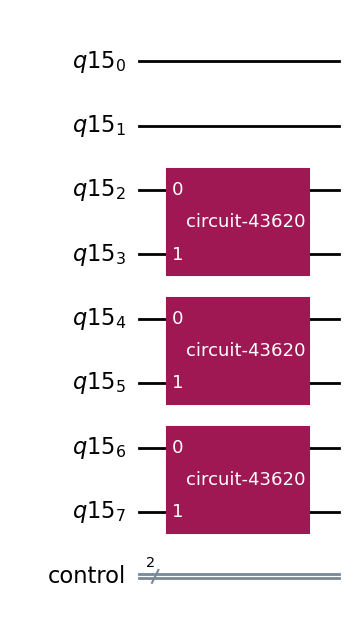

QiskitError: 'ERROR:  [Experiment 0] Insufficient memory to run circuit circuit-43619 using the density_matrix simulator. Required memory: 18446744073709551615M, max memory: 32768M ,  ERROR: Insufficient memory to run circuit circuit-43619 using the density_matrix simulator. Required memory: 18446744073709551615M, max memory: 32768M'

In [ ]:
#trying to perform testrun with the corresponing noise model, but haven't been able to do it, still working 6/10

import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import state_fidelity, Statevector
from qiskit.transpiler import CouplingMap, Layout

k               = 2
single_control  = False
t, J, h         = 1, 1, 1
N_qpa           = 0
steps           = 1


if single_control and k == 3:
    # trace_out = [0, 4, 5, 6, 7, 8, 9]
    # trace_out = [0, 1, 2, 3, 7, 8, 9] #seem to have weird noise
    trace_out = [0, 1, 2, 3, 4, 5, 6]
elif single_control and k == 2:
    trace_out = [0, 3, 4, 5, 6]
elif not single_control and k == 3:
    trace_out = [0, 1, 2, 6, 7, 8, 9, 10, 11] #seem to have weird noise
    # trace_out = [0, 1, 2, 3, 4, 5, 9, 10, 11]
    # trace_out = [0, 1, 2, 3, 4, 5, 6, 7, 8]
elif not single_control and k == 2:
    trace_out = [0, 1, 4, 5, 6, 7]

sim = AerSimulator(method="density_matrix", noise_model=noise_model)
# sim = AerSimulator(method="density_matrix", noise_model=None)

# build ising instance + ideal reference
ising            = ising_class(k, steps, t, J, h)
psi_exact        = ising.get_trotterized_ising_statevector()      # Statevector

# build QPA circuit (no measurement)
qc_nom           = get_QPA_circuit(k, N_qpa, ising, single_control)
qc_nom           = qc_nom.remove_final_measurements(inplace=False)

display(qc_nom.draw('mpl'))
# compact layout onto qubits 0…n-1
n                = qc_nom.num_qubits
used_virtuals    = qc_nom.qubits

qc_fakebackend_transpiled = transpile(qc_nom, backend=fake_backend, optimization_level=3)
layout = qc_fakebackend_transpiled.layout.initial_layout

trimmed_dict = {v: p for v, p in layout.get_virtual_bits().items()
                if v in used_virtuals}
trimmed_layout = Layout(trimmed_dict)          # a plain Layout, no extras

# result  = sim.run(qc_fakebackend_transpiled).result()        # same noise model, same basis_gates

qc_map           = transpile(
    qc_nom,
    basis_gates=basis_gates,
    # coupling_map=CouplingMap.from_full(n),
    initial_layout=trimmed_layout,
    optimization_level=3,
)

# display(qc_map.draw('mpl'))

# # save density matrix & simulate (single shot)
qc_map.save_density_matrix(label="rho")
rho_full         = DensityMatrix(sim.run(qc_map , shots=1).result().data(0)["rho"])

# # trace out unwanted qubits
# rho_reduced      = partial_trace(rho_full, trace_out)

# # fidelity (ρ, |ψ⟩)

# # Assume:
# # - rho_traced_out is a qiskit DensityMatrix object
# # - noiseless_state is a Statevector (or 1D normalized numpy array)

# # 1. Convert to matrix form
# rho_mat = rho_reduced.data

# # 2. Diagonalize
# eigvals, eigvecs = np.linalg.eigh(rho_mat)
# print(eigvals)

# # 3. Wrap target pure state
# pure = psi_exact.data

# # 4. Compute fidelity with each eigenvector
# fidelities = [np.abs(np.vdot(pure, eigvecs[:, i]))**2 for i in range(len(eigvals))]
# print("fidelities:", fidelities)

# # 5. Plot spectrum
# plt.figure(figsize=(6, 4))
# plt.bar(range(len(eigvals)), eigvals, alpha=0.6, label="Eigenvalues")
# plt.plot(range(len(eigvals)), fidelities, 'o-', label="Fidelity with |ψ⟩")
# plt.xlabel("Eigenvector index")
# plt.ylabel("Value")
# plt.title("Spectrum of ρ and Fidelity with Target |ψ⟩")
# plt.legend()
# plt.tight_layout()
# plt.show()
# print(layout)

In [34]:
props=fake_backend.properties()
print("T1(us)", props.t1(3), "gate error X4", props.gate_error('x', [3]))
print("T1(us)", props.t1(4), "gate error X4", props.gate_error('x', [4]))
print("T1(us)", props.t1(5), "gate error X4", props.gate_error('x', [5]))
print("T1(us)", props.t1(6), "gate error X4", props.gate_error('x', [6]))
print("T1(us)", props.t1(126), "gate error X4", props.gate_error('x', [126]))
print(trimmed_layout)

T1(us) 0.0003950714518574457 gate error X4 0.00016870151765073073
T1(us) 0.00040317076079271166 gate error X4 0.0002489406132925949
T1(us) 0.00011388133067137412 gate error X4 1
T1(us) 0.00023740349651795418 gate error X4 0.0003294099104723003
T1(us) 0.0003561004550988377 gate error X4 0.00016842723028581612
Layout({
4: <Qubit register=(8, "q15"), index=2>,
3: <Qubit register=(8, "q15"), index=3>,
65: <Qubit register=(8, "q15"), index=4>,
66: <Qubit register=(8, "q15"), index=5>,
53: <Qubit register=(8, "q15"), index=6>,
60: <Qubit register=(8, "q15"), index=7>,
0: <Qubit register=(8, "q15"), index=0>,
1: <Qubit register=(8, "q15"), index=1>
})


### Scan over $N_\mathrm{trot}$ and see Fidelity

In [9]:
# -----------------------------------------------------------
# 0 ––  simulation constants
# -----------------------------------------------------------
k               = 3
single_control  = False
t, J, h         = 1, 1, 1
N_qpa           = 0

if single_control and k == 3:
    trace_out = [0, 4, 5, 6, 7, 8, 9]
elif single_control and k == 2:
    trace_out = [0, 3, 4, 5, 6]
elif not single_control and k == 3:
    trace_out = [0, 1, 2, 6, 7, 8, 9, 10, 11]
elif not single_control and k == 2:
    trace_out = [0, 1, 4, 5, 6, 7]

# fake backend + delay-free noise model
fb          = FakeSherbrooke()
noise_model = NoiseModel.from_backend(fb, thermal_relaxation=False)
basis_gates = noise_model.basis_gates
sim         = AerSimulator(method="density_matrix", noise_model=noise_model)

# -----------------------------------------------------------
# 1 ––  helper: fidelity for a given trotter step-count
# -----------------------------------------------------------
def fidelity_for_steps_dm(steps: int) -> float:
    # build ising instance + ideal reference
    ising            = ising_class(k, steps, t, J, h)
    psi_exact        = ising.get_trotterized_ising_statevector()      # Statevector
    
    # build QPA circuit (no measurement)
    qc_nom           = get_QPA_circuit(k, N_qpa, ising, single_control=single_control)
    qc_nom           = qc_nom.remove_final_measurements(inplace=False)
    
    # compact layout onto qubits 0…n-1
    n                = qc_nom.num_qubits
    layout           = Layout({q: i for i, q in enumerate(qc_nom.qubits)})
    qc_map           = transpile(
        qc_nom,
        basis_gates=basis_gates,
        coupling_map=CouplingMap.from_full(n),
        initial_layout=layout,
        optimization_level=3,
    )
    
    # save density matrix & simulate (single shot)
    qc_map.save_density_matrix(label="rho")
    rho_full         = DensityMatrix(sim.run(qc_map, shots=1).result().data(0)["rho"])
    
    # trace out unwanted qubits
    rho_reduced      = partial_trace(rho_full, trace_out)
    
    # fidelity (ρ, |ψ⟩)
    return state_fidelity(rho_reduced, psi_exact)

# -----------------------------------------------------------
# 2 ––  scan steps = 1 … 20
# -----------------------------------------------------------
steps_list   = list(range(1, 21))
fid_list     = [fidelity_for_steps_dm(s) for s in steps_list]

key = f"d={k}_single_control{single_control}"

output_dir = "fidelity_results"
os.makedirs(output_dir, exist_ok=True)

# Save CSV
df = pd.DataFrame({"Trotter Step": steps_list, "Fidelity": fid_list})
df.to_csv(os.path.join(output_dir, f"{key}.csv"), index=False)

KeyboardInterrupt: 

### Measure fidelity v.s. trotter steps with Fake backend

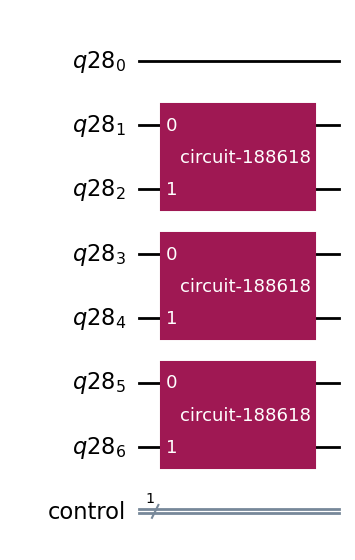

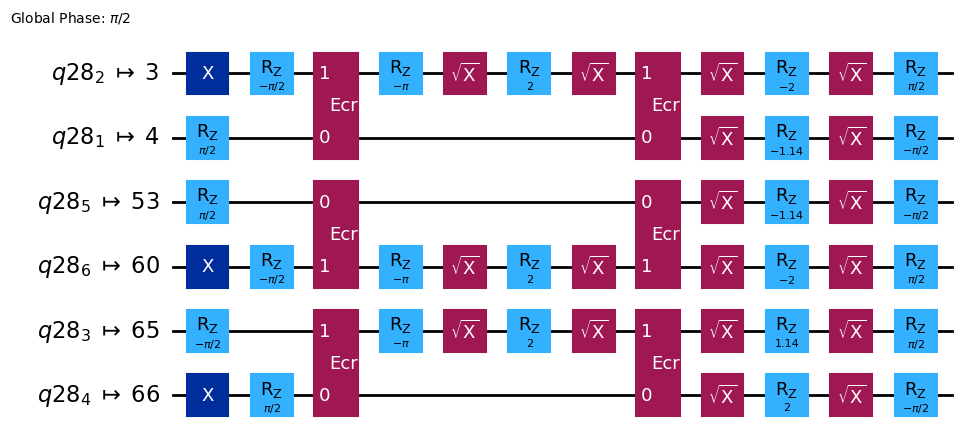

In [127]:
k               = 2
single_control  = True
reduced_if      = True
t, J, h         = 1, 1, 1
N_qpa           = 0
steps           = 10


if single_control and k == 3:
    trace_out = [0, 4, 5, 6, 7, 8, 9]
elif single_control and k == 2:
    trace_out = [0, 3, 4, 5, 6]
elif not single_control and k == 3:
    trace_out = [0, 1, 2, 6, 7, 8, 9, 10, 11]
elif not single_control and k == 2:
    trace_out = [0, 1, 4, 5, 6, 7]

psi_exact        = ising.get_trotterized_ising_statevector()
qc_nom           = get_QPA_circuit(k, N_qpa, ising, single_control, reduced_if)
display(qc_nom.draw('mpl'))

def get_projector(psi_exact, single_control= False):
    fidelity_operator = SparsePauliOp.from_operator(psi_exact.to_operator())
    identity_op = SparsePauliOp(["I" * (k)])
    if single_control:
        control_identity = SparsePauliOp(["I"])
    else:
        control_identity = identity_op
    full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(control_identity)
    # full_space_fidelity_operator = identity_op.tensor(fidelity_operator).tensor(identity_op).tensor(control_identity)
    return full_space_fidelity_operator


full_space_fidelity_operator = get_projector(psi_exact, single_control)
qc_transpiled_0 = transpile(qc_nom, backend=fake_backend, optimization_level=3)


display(qc_transpiled_0.draw('mpl'))

# layout_0 = qc_transpiled_0.layout
# observable_0 = full_space_fidelity_operator.apply_layout(layout_0)
# estimator = EstimatorV2(mode=fake_backend)
# estimator.options.default_shots = 1024
# # job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()
# job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()

# fidelity0 = job0[0].data.evs
# print(fidelity0)

In [ ]:
# -----------------------------------------------------------
# 0 –– simulation constants
# -----------------------------------------------------------
k               = 3
single_control  = True
t, J, h         = 1, 1, 1
N_qpa           = 0

# -----------------------------------------------------------
# 1 –– helper: fidelity via Estimator V2 for a given step-count
# -----------------------------------------------------------
def fidelity_for_steps_est(steps: int) -> float:
    # 1. exact reference state |ψ⟩
    ising            = ising_class(k, steps, t, J, h)
    psi_exact      = ising.get_trotterized_ising_statevector()
    full_space_fidelity_operator = get_projector(psi_exact, single_control)

    # 2. build projector ⟨ψ|·|ψ⟩ extended to full register
    fid_op        = SparsePauliOp.from_operator(psi_exact.to_operator())
    id_op         = SparsePauliOp(["I" * k])
    ctrl_id       = SparsePauliOp(["I"]) if single_control else id_op
    full_op       = fid_op.tensor(id_op).tensor(id_op).tensor(ctrl_id)

    # 3. QPA circuit (no final measurements)
    qc_nom        = get_QPA_circuit(k, N_qpa, ising, single_control=single_control)

    # 4. map to full-connectivity, noise-aware transpilation
    qc_transpiled_0 = transpile(qc_nom, backend=fake_backend, optimization_level=3)
    layout_0 = qc_transpiled_0.layout
    observable_0 = full_space_fidelity_operator.apply_layout(layout_0)
    estimator = EstimatorV2(mode=fake_backend)
    estimator.options.default_shots = 1024
    # job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()
    ev = estimator.run([(qc_transpiled_0, observable_0, None)]).result()[0].data.evs
    return float(ev)          # fidelity

# -----------------------------------------------------------
# 2 –– scan steps = 1 … 20
# -----------------------------------------------------------
steps_list = list(range(1, 21))
fid_list   = [fidelity_for_steps_est(s) for s in steps_list]


key = f"k={k}_single_control{single_control}_ev2"

output_dir = "fidelity_results"
os.makedirs(output_dir, exist_ok=True)

# Save CSV
df = pd.DataFrame({"Trotter Step": steps_list, "Fidelity": fid_list})
df.to_csv(os.path.join(output_dir, f"{key}.csv"), index=False)


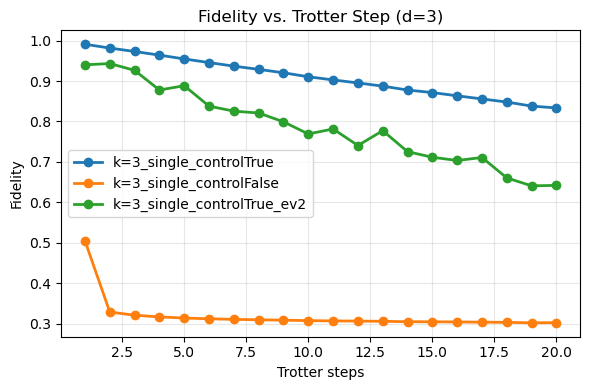

In [24]:
# plot the spectra for different configurations
# File paths
folder = "fidelity_results"
files = [
    "k=3_single_controlTrue.csv",
    "k=3_single_controlFalse.csv",
    "k=3_single_controlTrue_ev2.csv",
    # "d=3_single_controlFalse_ev2.csv"
]

# Plot
plt.figure(figsize=(6, 4))
for file in files:
    df = pd.read_csv(os.path.join(folder, file))
    label = file.replace(".csv", "")
    plt.plot(df["Trotter Step"], df["Fidelity"], marker='o', lw=2, label=label)

plt.xlabel("Trotter steps")
plt.ylabel("Fidelity")
plt.title("Fidelity vs. Trotter Step (d=3)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import random
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeBrisbane

def random_pauli_circuit(n_qubits: int) -> QuantumCircuit:
    """Create a circuit that applies a random Pauli X, Y, or Z
    to each qubit, then measures in the computational basis."""
    qc = QuantumCircuit(n_qubits)
    paulis = ['x', 'y', 'z']          # choose among X, Y, Z
    for q in range(n_qubits):
        getattr(qc, random.choice(paulis))(q)
    qc.measure_all()
    return qc

# configurable parameters
n_qubits = 3
shots = 10240

# build the circuit
qc = random_pauli_circuit(n_qubits)
print(qc)
qc_traspiled = transpile(qc, backend=fake_backend, optimization_level=3)
print(qc_transpiled)
# set up the Sampler with the Fake Sherbrooke noise model
sampler = SamplerV2(mode=fake_backend)

# run and collect quasi-probabilities
result = sampler.run([qc_traspiled], shots=shots).result()
dist = result[0].data.meas.get_counts()
print(dist)

# probability of observing the all-zero bit-string
p_all_zero = dist.get(0, 0.0)      # integer 0 ↔ "0…0"

print(f"Probability of all-zero string: {p_all_zero:.4f}")


        ┌───┐ ░ ┌─┐      
   q_0: ┤ X ├─░─┤M├──────
        ├───┤ ░ └╥┘┌─┐   
   q_1: ┤ Y ├─░──╫─┤M├───
        ├───┤ ░  ║ └╥┘┌─┐
   q_2: ┤ X ├─░──╫──╫─┤M├
        └───┘ ░  ║  ║ └╥┘
meas: 3/═════════╩══╩══╩═
                 0  1  2 
global phase: 7π/4
          ┌────────┐ ┌────┐          ┌──────┐┌──────────┐┌────┐┌─────────┐
q_0 -> 0 ─┤ Rz(-π) ├─┤ √X ├──────────┤1     ├┤ Rz(-π/2) ├┤ √X ├┤ Rz(π/2) ├
         ┌┴────────┴┐├────┤┌────────┐│  Ecr │├─────────┬┘├────┤├─────────┤
q_1 -> 1 ┤ Rz(-π/2) ├┤ √X ├┤ Rz(-π) ├┤0     ├┤ Rz(π/2) ├─┤ √X ├┤ Rz(π/2) ├
         └──────────┘└────┘└────────┘└──────┘└─────────┘ └────┘└─────────┘
Probability of all-zero string: 0.0000


In [112]:
#https://quantumcomputing.stackexchange.com/questions/38780/how-to-run-the-qiskit-sampler-after-storing-measurement-results-on-classical-qub
dist= result[0].data.meas.get_counts()
dist

{'111': 10058, '101': 62, '011': 69, '110': 49, '010': 2}

Original depth: 15
Transpiled depth: 20


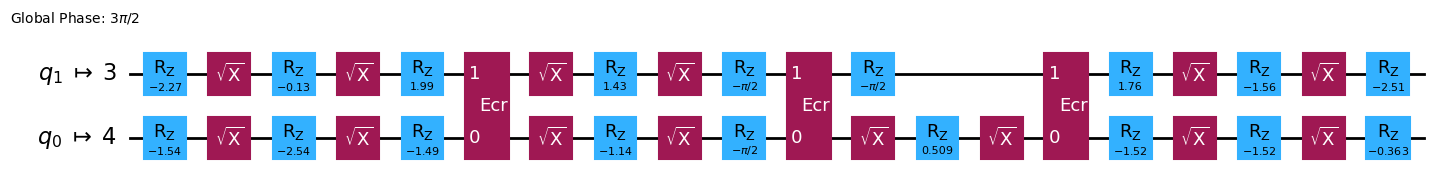

In [138]:
qc = QuantumCircuit(2)
qc.cx(0, 1)
qc.rx(np.pi/4, 0)
qc.cx(1, 0)
qc.ry(np.pi/3, 1)
qc.cx(0, 1)
qc.rz(np.pi/5, 0)
qc.cx(0, 1)
qc.rx(np.pi/3, 0)
qc.cx(0, 1)
qc.ry(np.pi/4, 1)
qc.cx(1, 0)
qc.rz(np.pi/5, 0)
qc.cx(0, 1)
qc.rx(np.pi/3, 0)
qc.cx(0, 1)

transpiled = transpile(qc, backend=FakeSherbrooke(), optimization_level=3)
print(f"Original depth: {qc.depth()}")
print(f"Transpiled depth: {transpiled.depth()}")
display(transpiled.draw('mpl'))